In [56]:
from app_recouple import *
import pandas as pd

In [57]:
db = pd.read_csv('predictions.txt')
ars = pd.read_csv('ars.csv')
flare_actual = pd.read_csv('Flares.csv')

In [58]:
def get_flare(date_param, df):
    """
    Checks if there are any records in the dataframe where isFlare is True
    and largestEventDate is within the date_param and 24 hours after.

    Parameters:
    date_param (datetime): The date to check against.
    df (DataFrame): The dataframe containing the records.

    Returns:
    DataFrame: A dataframe containing the matching records.
    """
    # Convert the date_param to datetime if it is not already
    if not isinstance(date_param, pd.Timestamp):
        date_param = pd.to_datetime(date_param)

    # Define the end date (24 hours after date_param)
    end_date = date_param + timedelta(hours=24)
    end_date = pd.to_datetime(end_date).tz_localize(None)
    date_param = pd.to_datetime(date_param).tz_localize(None)

    # print(date_param.values[0])
    # print(end_date.values[0])
    # print(type(end_date.values[0]))

    # Filter the dataframe
    result = df[(df['Is_Flare'] == True) & 
                (pd.to_datetime(df['Largest Event Date']) >= pd.to_datetime(date_param)) & 
                (pd.to_datetime(df['Largest Event Date']) < pd.to_datetime(end_date))]


    # result = df[(df['Is_Flare'] == True) & 
    #             (df['Largest Event Date'] >= date_param) & 
    #             (df['Largest Event Date'] < end_date)]

    return result

In [59]:
# Find the row with the specific timestamp in the DataFrame
def get_metrics(row,plage,events):
    try:
        guidedgradcam = retrieve_npy(row['local_request_date'],root='guidedgradcam')
        original = retrieve_npy(row['local_request_date'],root='original')
        ar_names,ar_lat,ar_lon = retrieve_ar(row['local_request_date'],
        plage=plage ,
        events=events
        )

        actual_pred = get_flare(row['obs_date'],flare_actual)
        # if actual_pred.shape[0] >= 1:
        #     actual_pred = 1
        # else:
        #     actual_pred = 0

        pix_list = [post_hoc_explanation.convert_to_pix(float(x[1]),float(x[0])) for x in zip(ar_lat,ar_lon)]
        flares = [item for item in list(zip(ar_names,pix_list))]

        # Analyze attention map
        bounding_hulls_img, distances_df, score, ratio = post_hoc_explanation.explain(guidedgradcam, flares, -20, 20, 35, 40, 30, 50, 2, 10, numpy=True)
    except Exception as e:
        return None, None, None, actual_pred.shape[0]
    return  distances_df.to_dict(orient='list'), score, ratio,actual_pred.shape[0]

In [60]:
db[['distances_df_all', 'score_all', 'ratio_all','actual']] = db.apply(
    lambda row: pd.Series(get_metrics(row, True, True)), axis=1
    
)

# for idx,row, in db.iterrows():
#     print(idx, row['obs_date'])
#     try:
#         distances_df, score, ratio  = get_metrics(row, False, False)
#     except Exception as e:
#         print(e)



In [61]:
# db.to_csv('processed_alexnet.csv',index=False)

In [62]:

# Assuming df is your DataFrame
# Step 1: Convert local_request_date to datetime format
db['local_request_date'] = pd.to_datetime(db['local_request_date'])
print(db.shape)

# Step 2: Filter out rows where ratio is NaN
df_filtered = db.dropna(subset=['score_all']).reset_index(drop=True)
print(df_filtered.shape)

# Step 3: Extract year, month, and day
df_filtered['year'] = df_filtered['local_request_date'].dt.year
df_filtered['month'] = df_filtered['local_request_date'].dt.month
df_filtered['day'] = df_filtered['local_request_date'].dt.day

# Step 4: Group by year and month, then count the number of unique days
result = df_filtered.groupby(['year', 'month'])['day'].nunique().reset_index()

# Rename the 'day' column to 'unique_days' for clarity
result = result.rename(columns={'day': 'unique_days'})

# print(result)


(5922, 13)
(5307, 13)


In [63]:
df_filtered['actual_pred']=df_filtered['actual'].apply(lambda x: 1 if x >= 1.0 else 0)
df_filtered['actual'].value_counts()
df_filtered['score_all_bound'] = df_filtered['score_all']/400
# df_filtered[(df_filtered.actual_pred != 0) & (df_filtered.actual <1)][['actual_pred','actual']]

In [64]:
import pandas as pd

# Assuming df is your DataFrame with 'scored_probabilities' and 'actual' fields
# Define the threshold
threshold = 0.5

# Step 1: Get predicted labels based on the threshold
df_filtered['predicted'] = df_filtered['flare_probability'].apply(lambda x: 1 if x >= threshold else 0)

# Step 2: Classify each record as FP, TP, FN, or TN
def classify(row):
    if row['predicted'] == 1 and row['actual_pred'] == 1:
        return 'TP'
    elif row['predicted'] == 1 and row['actual_pred'] == 0:
        return 'FP'
    elif row['predicted'] == 0 and row['actual_pred'] == 1:
        return 'FN'
    elif row['predicted'] == 0 and row['actual_pred'] == 0:
        return 'TN'

df_filtered['classification'] = df_filtered.apply(classify, axis=1)

# Display the DataFrame with the new column
print(df_filtered['classification'].value_counts())


classification
TN    4412
FP     406
TP     316
FN     173
Name: count, dtype: int64


In [65]:
# Group by classification and calculate descriptive statistics for the ratio field
stats = df_filtered.groupby('classification')['ratio_all'].describe()
stats

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
FN,173.00,0.67,0.29,0.00,0.50,0.67,1.00,1.00
FP,406.00,0.72,0.26,0.00,0.50,0.75,1.00,1.00
TN,4412.00,0.74,0.31,0.00,0.50,0.80,1.00,1.00
TP,316.00,0.79,0.25,0.20,0.60,0.81,1.00,1.00


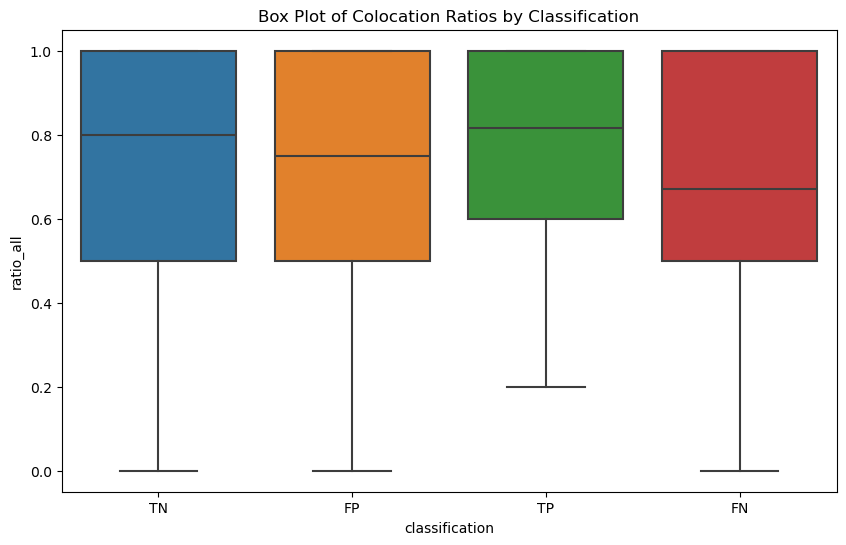

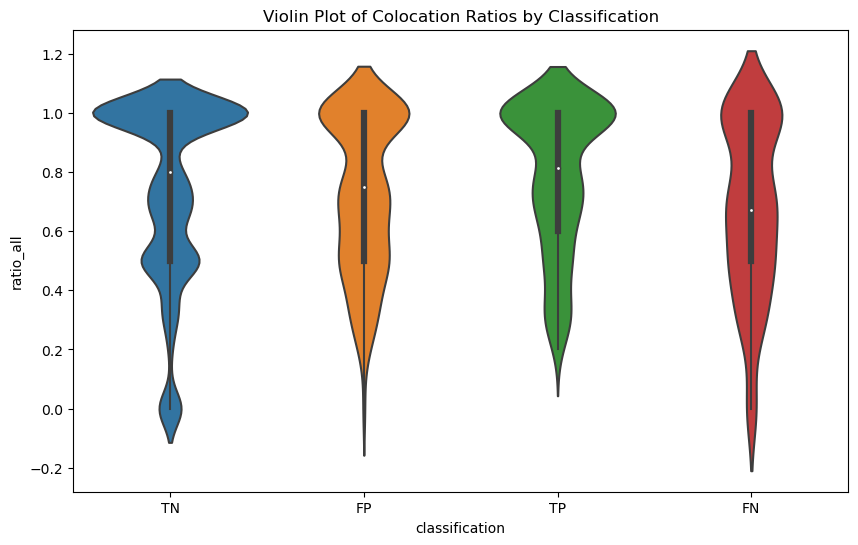

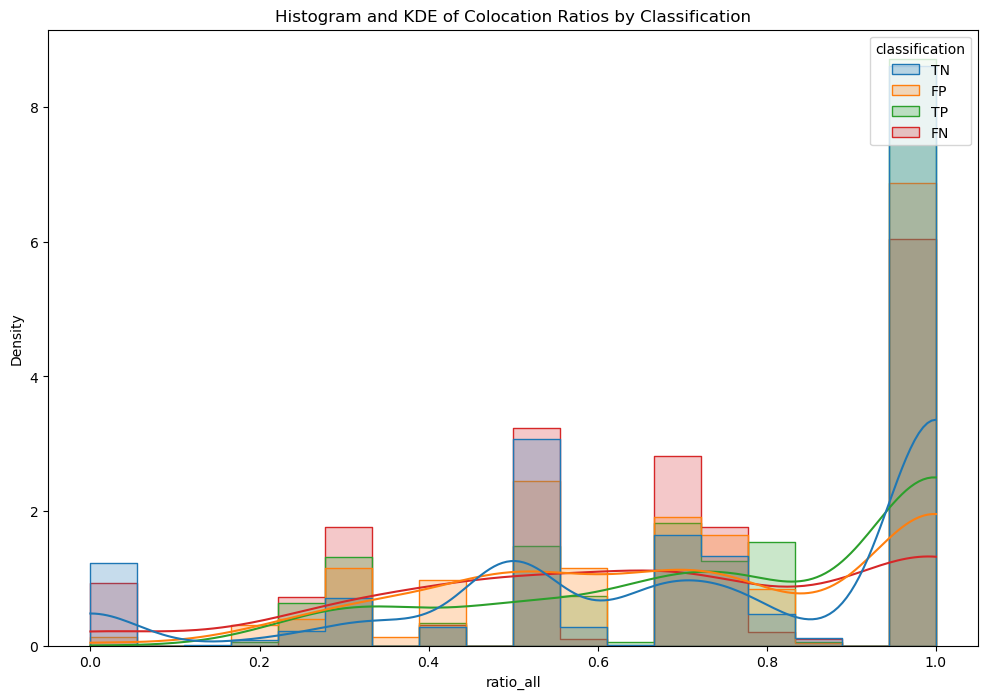

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a DataFrame 'df' with columns 'colocation_ratio' and 'classification'

# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='ratio_all', data=df_filtered)
plt.title('Box Plot of Colocation Ratios by Classification')
plt.show()

# Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='classification', y='ratio_all', data=df_filtered)
plt.title('Violin Plot of Colocation Ratios by Classification')
plt.show()

# Histogram and KDE Plot
plt.figure(figsize=(12, 8))
sns.histplot(data=df_filtered, x='ratio_all', hue='classification', kde=True, element='step', stat='density', common_norm=False)
plt.title('Histogram and KDE of Colocation Ratios by Classification')
plt.show()


In [67]:
# Group by classification and calculate descriptive statistics for the ratio field
stats = df_filtered.groupby('classification')['score_all'].describe()
stats

,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
FN,173.00,30.98,40.25,0.00,0.00,21.73,41.10,212.68
FP,406.00,21.90,33.82,0.00,0.00,7.68,28.14,207.12
TN,4412.00,26.45,44.98,0.00,0.00,2.35,35.07,317.03
TP,316.00,19.74,30.90,0.00,0.00,0.39,31.68,128.43


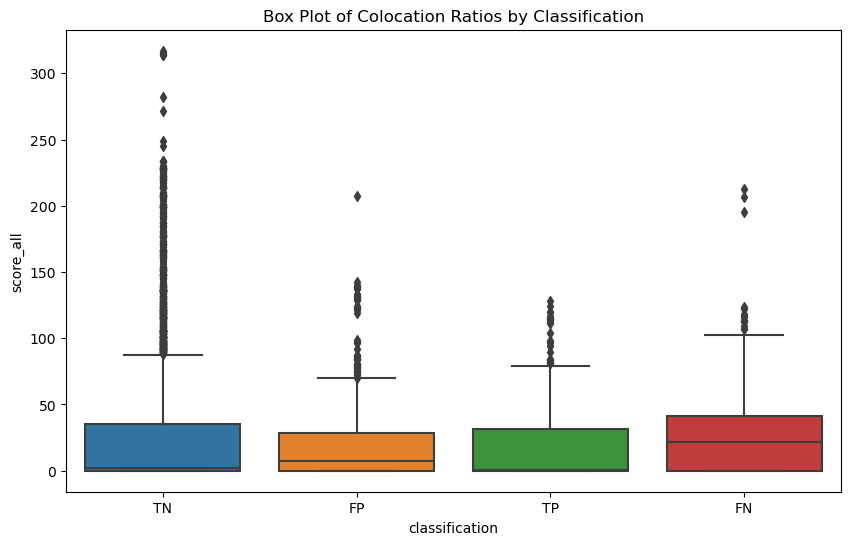

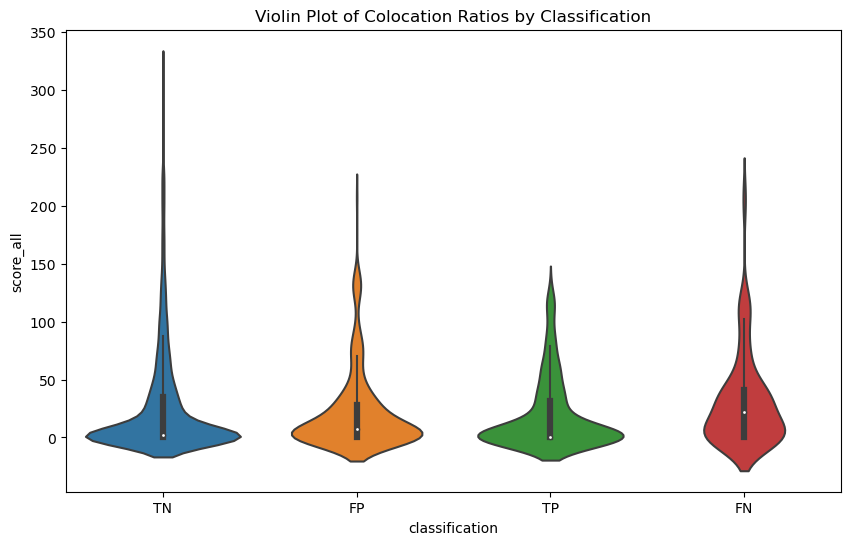

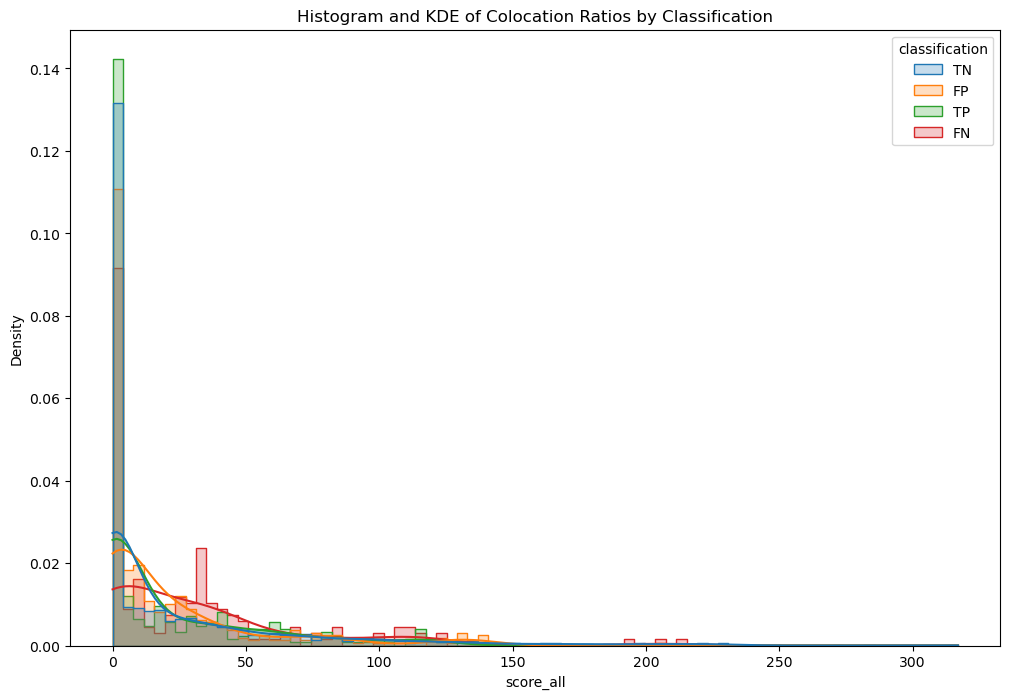

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have a DataFrame 'df' with columns 'colocation_ratio' and 'classification'

# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='score_all', data=df_filtered)
plt.title('Box Plot of Colocation Ratios by Classification')
plt.show()

# Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='classification', y='score_all', data=df_filtered)
plt.title('Violin Plot of Colocation Ratios by Classification')
plt.show()

# Histogram and KDE Plot
plt.figure(figsize=(12, 8))
sns.histplot(data=df_filtered, x='score_all', hue='classification', kde=True, element='step', stat='density', common_norm=False)
plt.title('Histogram and KDE of Colocation Ratios by Classification')
plt.show()


## ANOVA

In [69]:
import scipy.stats as stats

df = df_filtered
# Perform ANOVA
anova_result = stats.f_oneway(df[df['classification'] == 'TN']['score_all'],
                              df[df['classification'] == 'FP']['score_all'],
                              df[df['classification'] == 'TP']['score_all'],
                              df[df['classification'] == 'FN']['score_all'])
print('ANOVA result:', anova_result)

# Perform pairwise t-tests
t_test_TN_FP = stats.ttest_ind(df[df['classification'] == 'TN']['score_all'], 
                               df[df['classification'] == 'FP']['score_all'])
t_test_TN_TP = stats.ttest_ind(df[df['classification'] == 'TN']['score_all'], 
                               df[df['classification'] == 'TP']['score_all'])
t_test_TN_FN = stats.ttest_ind(df[df['classification'] == 'TN']['score_all'], 
                               df[df['classification'] == 'FN']['score_all'])

print('T-test TN vs FP:', t_test_TN_FP)
print('T-test TN vs TP:', t_test_TN_TP)
print('T-test TN vs FN:', t_test_TN_FN)


ANOVA result: F_onewayResult(statistic=4.303284845237409, pvalue=0.004868399378735045)
T-test TN vs FP: TtestResult(statistic=1.9870093040105254, pvalue=0.04697792970404579, df=4816.0)
T-test TN vs TP: TtestResult(statistic=2.6067369697314096, pvalue=0.009169666421651866, df=4726.0)
T-test TN vs FN: TtestResult(statistic=-1.3050177653666921, pvalue=0.19195231674772428, df=4583.0)


In [70]:
import scipy.stats as stats

df = df_filtered
# Perform ANOVA
anova_result = stats.f_oneway(df[df['classification'] == 'TN']['ratio_all'],
                              df[df['classification'] == 'FP']['ratio_all'],
                              df[df['classification'] == 'TP']['ratio_all'],
                              df[df['classification'] == 'FN']['ratio_all'])
print('ANOVA result:', anova_result)

# Perform pairwise t-tests
t_test_TN_FP = stats.ttest_ind(df[df['classification'] == 'TN']['ratio_all'], 
                               df[df['classification'] == 'FP']['ratio_all'])
t_test_TN_TP = stats.ttest_ind(df[df['classification'] == 'TN']['ratio_all'], 
                               df[df['classification'] == 'TP']['ratio_all'])
t_test_TN_FN = stats.ttest_ind(df[df['classification'] == 'TN']['ratio_all'], 
                               df[df['classification'] == 'FN']['ratio_all'])

print('T-test TN vs FP:', t_test_TN_FP)
print('T-test TN vs TP:', t_test_TN_TP)
print('T-test TN vs FN:', t_test_TN_FN)


ANOVA result: F_onewayResult(statistic=6.00947439524507, pvalue=0.00043994501619858334)
T-test TN vs FP: TtestResult(statistic=1.0850077190467513, pvalue=0.27797254584581416, df=4816.0)
T-test TN vs TP: TtestResult(statistic=-2.680900654117855, pvalue=0.007367925771436249, df=4726.0)
T-test TN vs FN: TtestResult(statistic=2.863640595514297, pvalue=0.0042070505131084485, df=4583.0)


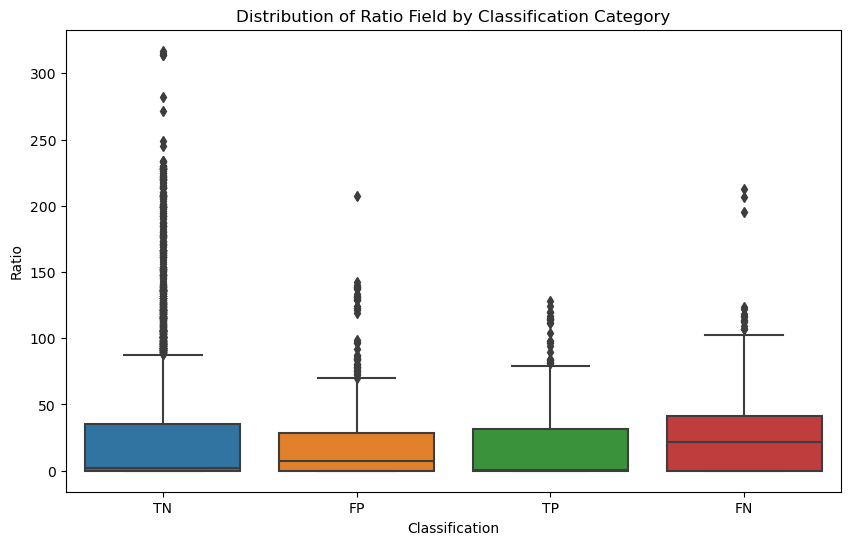

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot to visualize the ratio field for each classification category
plt.figure(figsize=(10, 6))
sns.boxplot(x='classification', y='score_all', data=df_filtered)
plt.title('Distribution of Ratio Field by Classification Category')
plt.xlabel('Classification')
plt.ylabel('Ratio')
plt.show()


<Figure size 1000x600 with 0 Axes>

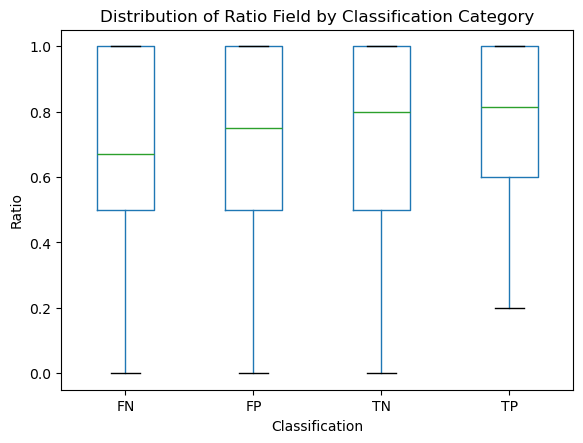

In [72]:
import matplotlib.pyplot as plt

# Create box plots
plt.figure(figsize=(10, 6))
df_filtered.boxplot(column='ratio_all', by='classification', grid=False)
plt.title('Distribution of Ratio Field by Classification Category')
plt.suptitle('')  # Suppress the default title
plt.xlabel('Classification')
plt.ylabel('Ratio')
plt.show()


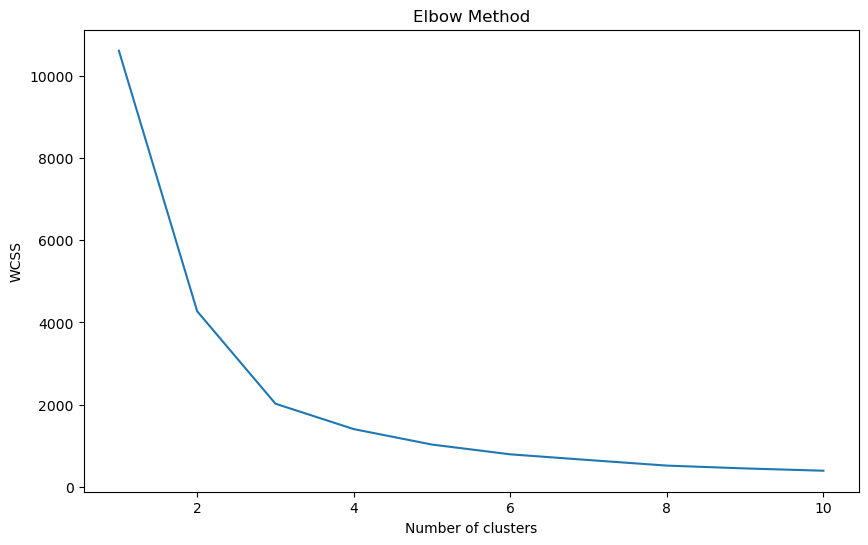

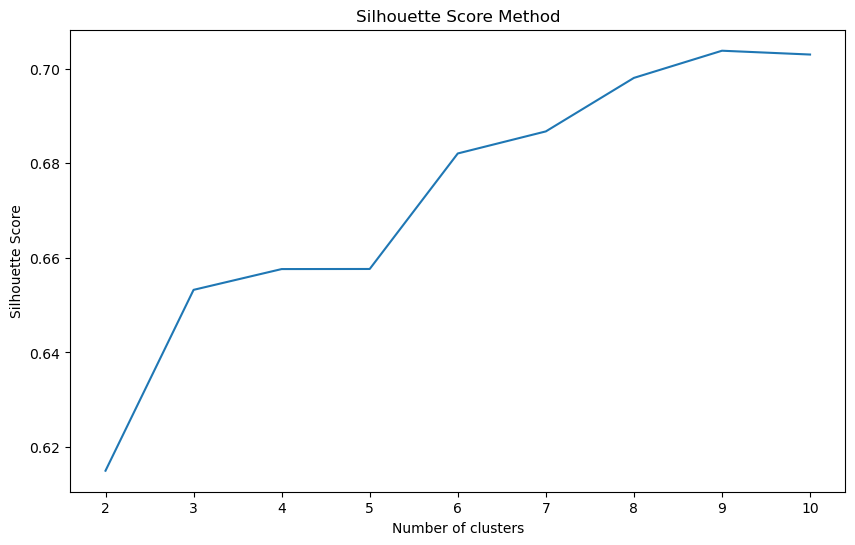

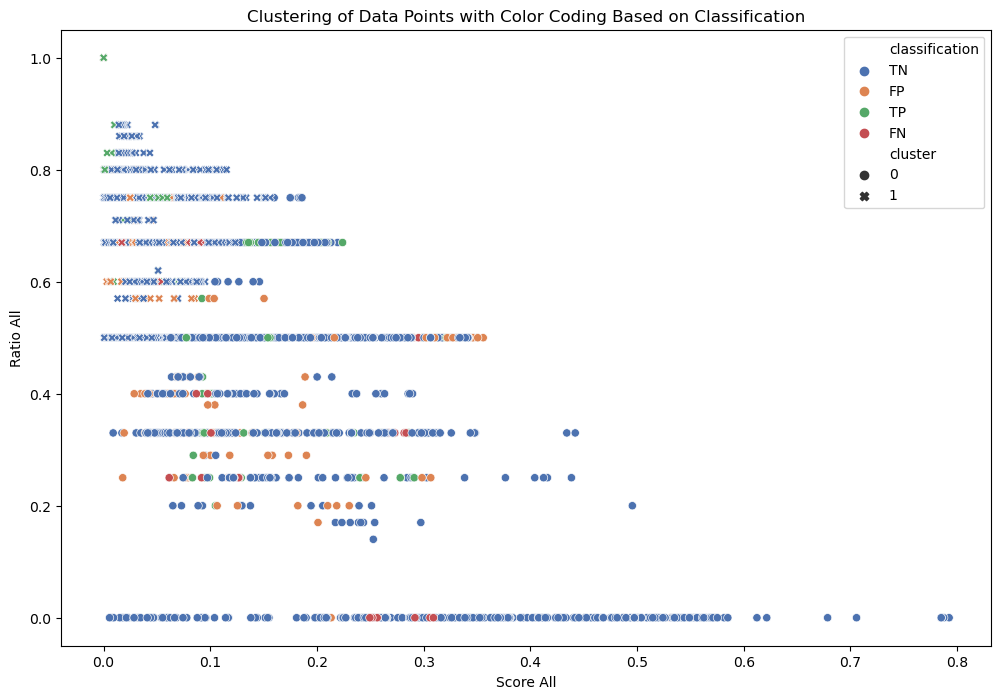

In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Assuming df is your DataFrame with 'score_all', 'ratio_all', and 'classification' fields
data = df_filtered[['score_all_bound', 'ratio_all']]

# Handle missing values if any
data = data.dropna()

# Standardize the data
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Using the Elbow Method to determine the optimal number of clusters
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Using Silhouette Score to determine the optimal number of clusters
silhouette_scores = []
for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(data_scaled)
    score = silhouette_score(data_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 11), silhouette_scores)
plt.title('Silhouette Score Method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Performing K-Means clustering with the chosen number of clusters (let's assume 4 for this example)
kmeans = KMeans(n_clusters=2, init='k-means++', max_iter=300, n_init=10, random_state=42)
df_filtered['cluster'] = kmeans.fit_predict(data_scaled)

# Visualizing the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(x='score_all_bound', y='ratio_all', hue='classification', style='cluster', palette='deep', data=df_filtered)
plt.title('Clustering of Data Points with Color Coding Based on Classification')
plt.xlabel('Score All')
plt.ylabel('Ratio All')
plt.legend(loc='best')
plt.show()


In [74]:
df_filtered

,source_date,obs_date,raw_filename,noaa_ar_filename,local_request_date,error,flare_probability,non_flare_probability,explanation,distances_df_all,...,ratio_all,actual,year,month,day,actual_pred,score_all_bound,predicted,classification,cluster
0,2015-01-01 00:18:09,2014-12-31T23:59:39.10Z,2014_12_31__23_59_39_105__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2015-01-01 00:00:00,NaN,0.31,0.69,NaN,"{'Flare': [12248, 12251, 12252, 12253], 'Close...",...,0.75,0.00,2015,1,1,0,0.03,0,TN,1
1,2015-01-01 04:21:05,2015-01-01T03:59:39.20Z,2015_01_01__03_59_39_205__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2015-01-01 04:00:00,NaN,0.34,0.66,NaN,"{'Flare': [12248, 12251, 12252, 12253], 'Close...",...,1.00,0.00,2015,1,1,0,0.00,0,TN,1
2,2015-01-01 08:20:03,2015-01-01T07:59:39.30Z,2015_01_01__07_59_39_305__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2015-01-01 08:00:00,NaN,0.59,0.41,NaN,"{'Flare': [12248, 12251, 12252, 12253], 'Close...",...,1.00,0.00,2015,1,1,0,0.00,1,FP,1
3,2015-01-01 12:18:08,2015-01-01T11:59:39.20Z,2015_01_01__11_59_39_205__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2015-01-01 12:00:00,NaN,0.61,0.39,NaN,"{'Flare': [12248, 12251, 12252, 12253], 'Close...",...,1.00,0.00,2015,1,1,0,0.00,1,FP,1
4,2015-01-01 16:20:06,2015-01-01T15:59:39.10Z,2015_01_01__15_59_39_105__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2015-01-01 16:00:00,NaN,0.86,0.14,NaN,"{'Flare': [12248, 12251, 12252, 12253], 'Close...",...,1.00,0.00,2015,1,1,0,0.00,1,FP,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5302,2017-09-09 20:19:19,2017-09-09T19:59:48.90Z,2017_09_09__19_59_48_905__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2017-09-09 20:00:00,NaN,0.56,0.44,NaN,"{'Flare': [12673, 12674, 12677, 12678, 12679],...",...,1.00,6.00,2017,9,9,1,0.00,1,TP,1
5303,2017-09-10 00:18:08,2017-09-09T23:59:49.00Z,2017_09_09__23_59_49_005__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2017-09-10 00:00:00,NaN,0.56,0.44,NaN,"{'Flare': [12673, 12674, 12678], 'Closest Hull...",...,0.33,6.00,2017,9,10,1,0.09,1,TP,0
5304,2017-09-10 04:16:34,2017-09-10T03:59:49.10Z,2017_09_10__03_59_49_105__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2017-09-10 04:00:00,NaN,0.64,0.36,NaN,"{'Flare': [12673, 12674, 12678], 'Closest Hull...",...,0.33,6.00,2017,9,10,1,0.09,1,TP,0
5305,2017-09-10 08:16:50,2017-09-10T07:59:49.10Z,2017_09_10__07_59_49_105__SDO_HMI_HMI_magnetog...,2024_7_02_0030_UTC.txt,2017-09-10 08:00:00,NaN,0.34,0.66,NaN,"{'Flare': [12673, 12674, 12678], 'Closest Hull...",...,0.33,6.00,2017,9,10,1,0.10,0,FN,0


In [75]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

# Load the Iris dataset
# data = load_iris()
# X = pd.DataFrame(data.data, columns=data.feature_names)
# y = pd.Series(data.target)

# Filtering based on 'TP' and 'FP'
df = df_filtered[df_filtered['classification'].isin(['FP', 'FN', 'TP',])]

X = df[['ratio_all','score_all']]
y = df['classification'].apply(lambda x: 1 if x in ['FP','FN'] else 0)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Initialize LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)

# Fit LazyClassifier on the training data and evaluate on the testing data
models, predictions = clf.fit(X_train, X_test, y_train, y_test)

100%|██████████████████████████████████████████████████████████████████████████████████| 29/29 [00:01<00:00, 21.77it/s]

[LightGBM] [Info] Number of positive: 461, number of negative: 255
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000076 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 250
[LightGBM] [Info] Number of data points in the train set: 716, number of used features: 2
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.643855 -> initscore=0.592134
[LightGBM] [Info] Start training from score 0.592134
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [76]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Time Taken
Model,,,,,
PassiveAggressiveClassifier,0.59,0.59,0.59,0.60,0.01
KNeighborsClassifier,0.54,0.57,0.57,0.55,0.01
NuSVC,0.52,0.57,0.57,0.52,0.03
DecisionTreeClassifier,0.65,0.56,0.56,0.62,0.02
XGBClassifier,0.66,0.56,0.56,0.62,0.08
NearestCentroid,0.53,0.55,0.55,0.53,0.00
ExtraTreeClassifier,0.66,0.55,0.55,0.61,0.02
LGBMClassifier,0.66,0.55,0.55,0.61,0.16
RandomForestClassifier,0.65,0.54,0.54,0.60,0.11
